# Hybrid Inference

This notebook demonstrates **hybrid inference** — the joint estimation of
**continuous** (e.g. robot poses) and **discrete** (e.g. semantic class)
variables — using GTSAM's `HybridNonlinearFactorGraph` machinery.

We work through three progressively richer examples:

1. **Discrete-only inference** — finding the Most Probable Explanation (MPE)
   of a binary variable given a `DecisionTreeFactor` prior.
2. **Continuous-only SLAM** — using `DCSAM` as a wrapper around iSAM2 for
   standard `Pose2` odometry SLAM.
3. **True hybrid inference** — a robot with an uncertain motion mode
   (normal vs. slippery surface) where `DCSAM` jointly estimates the pose
   trajectory *and* the active mode.

<a href="https://colab.research.google.com/github/borglab/gtsam/blob/develop/python/gtsam/examples/HybridInference.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [8]:
try:
    import google.colab
    %pip install --quiet gtsam-develop
except ImportError:
    pass  # Not running on Colab, do nothing

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

from gtsam import (
    DCSAM,
    BetweenFactorPose2,
    DecisionTreeFactor,
    DiscreteValues,
    HybridNonlinearFactor,
    HybridNonlinearFactorGraph,
    HybridValues,
    Pose2,
    PriorFactorPose2,
    Values,
    VectorValues,
    noiseModel,
)
from gtsam.symbol_shorthand import D, X

## Background

A **hybrid factor graph** contains three types of variables:

| Type | Example | Container |
|---|---|---|
| Continuous nonlinear | Pose $x_i \in SE(2)$ | `Values` |
| Continuous linear | IMU bias | `VectorValues` |
| Discrete | Motion mode $m \in \{0,1\}$ | `DiscreteValues` |

Factors can be **purely continuous** (`NonlinearFactor`), **purely discrete**
(`DecisionTreeFactor`), or **hybrid** (`HybridNonlinearFactor`).

### Discrete-Continuous Smoothing and Mapping (DCSAM)

We first demonstrate hybrid inference using the `DCSAM`
solver proposed by [Doherty *et al.* 2022](https://arxiv.org/abs/2204.11936)).

DCSAM is an iterative optimizer which alternates between:

1. **Continuous solve** — run iSAM2 with the discrete variables fixed at their current MPE.
2. **Discrete solve** — compute a `DiscreteBoundaryFactor` for each hybrid factor and find the new MPE by maximizing over the discrete variables.

---

## Example 1 — Discrete-only Inference

The simplest case: a single binary variable $D_1 \in \{0, 1\}$ with a
prior that strongly prefers $D_1 = 1$.  We expect DCSAM to return
$\hat{D}_1 = 1$.

In [ ]:
# DiscreteKey: (variable index, cardinality)
mode_key = D(1)
mode = (mode_key, 2)   # binary variable

# P(D1 = 0) = 0.1,  P(D1 = 1) = 0.9
dtf = DecisionTreeFactor(mode, "0.1 0.9")

hfg_discrete = HybridNonlinearFactorGraph()
hfg_discrete.push_back(dtf)

# Initial guess for the discrete variable
init_discrete = DiscreteValues()
init_discrete[mode_key] = 1

dcsam = DCSAM()
dcsam.update(hfg_discrete, init_discrete)
result_d = dcsam.calculateEstimate()

print(f"MPE for D(1): {result_d.atDiscrete(mode_key)}  (expected 1)")

MPE for D(1): 1  (expected 1)


---

## Example 2 — Continuous-only SLAM

An 8-pose 2-D SLAM problem: a robot follows a roughly octagonal path with
noisy odometry.  There are no discrete variables — `DCSAM` acts as a thin
wrapper around iSAM2.

In [ ]:
PRIOR_SIGMA = 0.1
ODOM_SIGMA  = 1.0

prior_noise = noiseModel.Isotropic.Sigma(3, PRIOR_SIGMA)
odom_noise  = noiseModel.Isotropic.Sigma(3, ODOM_SIGMA)

x0 = X(0)
pose0 = Pose2(0, 0, 0)
dx = Pose2(1, 0, np.pi / 4)  # 1 m forward, 45-degree turn
noise_pose = Pose2(0.01, 0.01, 0.01)  # small odometry noise

# ---- Graph ----
graph = HybridNonlinearFactorGraph()
# Prior on x0 at the origin
graph.push_back(PriorFactorPose2(x0, pose0, prior_noise))

# ---- Initial guess ----
init_cont = Values()
init_cont.insert(x0, pose0)

odom = Pose2(pose0)
for i in range(7):
    meas = dx.compose(noise_pose)
    graph.push_back(BetweenFactorPose2(X(i), X(i + 1), meas, odom_noise))
    odom = odom.compose(meas)
    init_cont.insert(X(i + 1), odom)

# ---- Solve ----
dcsam = DCSAM()
init_guess = HybridValues(DiscreteValues(), init_cont)
dcsam.update(graph, init_guess)
result = dcsam.calculateEstimate()

print("Continuous-only SLAM result (first three poses):")
for i in range(3):
    p = result.nonlinear().atPose2(X(i))
    print(f"  X({i}): x={p.x():.4f}, y={p.y():.4f}, θ={p.theta():.4f} rad")

Continuous-only SLAM result (first three poses):
  X(0): x=0.0000, y=0.0000, θ=-0.0000 rad
  X(1): x=1.0000, y=0.0141, θ=0.7954 rad
  X(2): x=1.6899, y=0.7382, θ=1.5908 rad


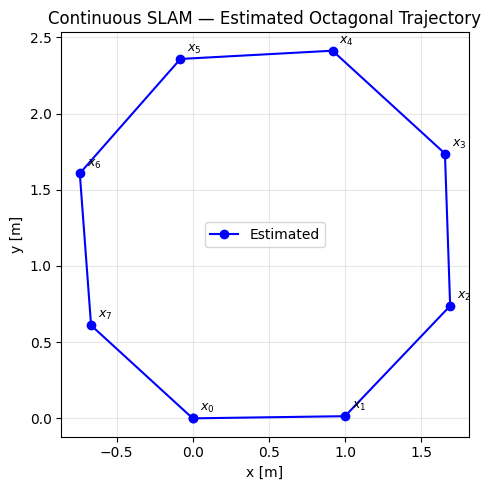

In [ ]:
# Visualize the estimated trajectory
est_xs = [result.nonlinear().atPose2(X(i)).x() for i in range(8)]
est_ys = [result.nonlinear().atPose2(X(i)).y() for i in range(8)]

fig, ax = plt.subplots(figsize=(6, 5))
ax.plot(est_xs + [est_xs[0]], est_ys + [est_ys[0]], 'b-o', label='Estimated')
for i in range(8):
    ax.annotate(f'$x_{i}$', (est_xs[i], est_ys[i]),
                textcoords='offset points', xytext=(5, 5), fontsize=9)
ax.set_xlabel('x [m]')
ax.set_ylabel('y [m]')
ax.set_title('Continuous SLAM — Estimated Octagonal Trajectory')
ax.legend()
ax.set_aspect('equal')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

---

## Example 3 — Hybrid Inference: Uncertain Motion Mode

### Problem description

A robot moves from $x_0$ to $x_1$ to $x_2$. The first odometry step has
an **uncertain mode** $D_0 \in \{0, 1\}$:

* **Mode 0 (normal)**: Reliable motion $\Delta x = (1, 0, 0)$ with
  small noise.
* **Mode 1 (slippery)**: Same nominal motion but with large noise.

The second odometry step is a known, pure-continuous `BetweenFactorPose2`.

A `DecisionTreeFactor` encodes a prior over the mode, and we also add
a discrete *observation* factor that says mode 0 is very likely.
After calling `DCSAM.update()`, we verify that:

* The discrete estimate is $\hat{D}_0 = 0$ (normal mode).
* The continuous estimates are close to the ground truth.

In [ ]:
# ---- Noise models ----
tight_noise = noiseModel.Isotropic.Sigma(3, 0.1)   # normal motion
loose_noise = noiseModel.Isotropic.Sigma(3, 2.0)   # slippery surface

# ---- Ground-truth motion ----
true_odom = Pose2(1.0, 0, 0)  # 1 m forward

# ---- Hybrid factor for the first odometry step ----
# Mode 0 → tight noise,  Mode 1 → loose noise
mode_key = D(0)
dk = (mode_key, 2)

odom_normal   = BetweenFactorPose2(X(0), X(1), true_odom, tight_noise)
odom_slippery = BetweenFactorPose2(X(0), X(1), true_odom, loose_noise)
hybrid_odom   = HybridNonlinearFactor(dk, [odom_normal, odom_slippery])

# ---- Graph ----
hfg = HybridNonlinearFactorGraph()

# Prior on x0 at the origin
hfg.push_back(PriorFactorPose2(X(0), Pose2(0, 0, 0),
                                noiseModel.Isotropic.Sigma(3, 0.01)))

# Hybrid first step
hfg.push_back(hybrid_odom)

# Known second step
hfg.push_back(BetweenFactorPose2(X(1), X(2), true_odom, tight_noise))

# Discrete prior: mode 0 (normal) is much more probable
hfg.push_back(DecisionTreeFactor(dk, "0.8 0.2"))

# Discrete observation: strong evidence for mode 0
hfg.push_back(DecisionTreeFactor(dk, "0.99 0.01"))

# ---- Initial guess ----
init_values = Values()
init_values.insert(X(0), Pose2(0, 0, 0))
init_values.insert(X(1), Pose2(1, 0, 0))  # nominal guess
init_values.insert(X(2), Pose2(2, 0, 0))

init_discrete = DiscreteValues()
init_discrete[mode_key] = 0

initial_guess = HybridValues(VectorValues(), init_discrete, init_values)

# ---- Solve ----
dcsam_hybrid = DCSAM()
dcsam_hybrid.update(hfg, initial_guess)
result_hybrid = dcsam_hybrid.calculateEstimate()

# Run a second iteration to refine
dcsam_hybrid.update()
result_hybrid = dcsam_hybrid.calculateEstimate()

print("Hybrid inference result")
print(f"  Discrete mode D(0): {result_hybrid.atDiscrete(mode_key)}  (expected 0 = normal)")
for i in range(3):
    p = result_hybrid.nonlinear().atPose2(X(i))
    print(f"  X({i}): x={p.x():.4f}, y={p.y():.4f}, θ={p.theta():.4f} rad")

Hybrid inference result
  Discrete mode D(0): 0  (expected 0 = normal)
  X(0): x=0.0000, y=0.0000, θ=0.0000 rad
  X(1): x=1.0000, y=0.0000, θ=0.0000 rad
  X(2): x=2.0000, y=0.0000, θ=0.0000 rad


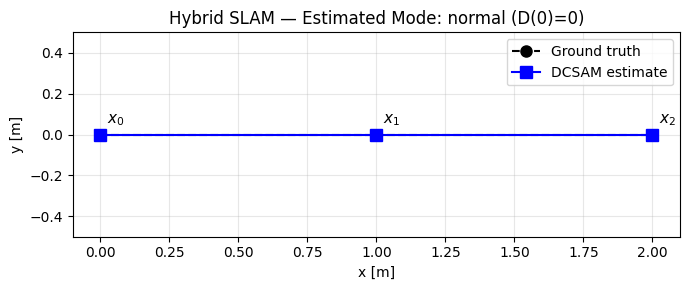

In [14]:
# Visualize hybrid SLAM result
hybrid_xs = [result_hybrid.nonlinear().atPose2(X(i)).x() for i in range(3)]
hybrid_ys = [result_hybrid.nonlinear().atPose2(X(i)).y() for i in range(3)]
gt_xs = [0.0, 1.0, 2.0]
gt_ys = [0.0, 0.0, 0.0]

fig, ax = plt.subplots(figsize=(7, 3))
ax.plot(gt_xs, gt_ys, 'k--o', markersize=8, label='Ground truth')
ax.plot(hybrid_xs, hybrid_ys, 'b-s', markersize=8, label='DCSAM estimate')
for i in range(3):
    ax.annotate(f'$x_{i}$', (hybrid_xs[i], hybrid_ys[i]),
                textcoords='offset points', xytext=(5, 8), fontsize=11)
mode_label = 'normal' if result_hybrid.atDiscrete(mode_key) == 0 else 'slippery'
ax.set_xlabel('x [m]')
ax.set_ylabel('y [m]')
ax.set_title(f'Hybrid SLAM — Estimated Mode: {mode_label} (D(0)={result_hybrid.atDiscrete(mode_key)})')
ax.legend()
ax.set_ylim(-0.5, 0.5)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### Details

DCSAM performed two rounds of alternating minimization:

1. **Round 1**:
   - *Continuous*: given the initial discrete guess (mode 0), iSAM2 pulls all poses towards the odometry mean.
   - *Discrete*: the `DiscreteBoundaryFactor` computed from the tight-noise component has a smaller negative log-likelihood at the current poses than the loose-noise component, so mode 0 is retained.

2. **Round 2** (`dcsam.update()` with no new factors):
   - Both steps refine slightly; the result converges.

The key insight is that DCSAM jointly estimates **where** the robot is *and*
**which motion model** was active — something that neither a pure-continuous
nor a pure-discrete solver can do alone.

---

## Summary

| Example | Variables | Method |
|---|---|---|
| Discrete-only | $D_1 \in \{0,1\}$ | `DCSAM.update(graph, DiscreteValues)` |
| Continuous-only | $x_0 \ldots x_7 \in SE(2)$ | `DCSAM.update(graph, HybridValues)` |
| Hybrid | $x_0, x_1, x_2 \in SE(2)$, $D_0 \in \{0,1\}$ | `DCSAM.update(graph, HybridValues)` |

Key classes used:

* `HybridNonlinearFactorGraph` — container for all factor types.
* `HybridNonlinearFactor` — selects a `NoiseModelFactor` for each mode.
* `DecisionTreeFactor` — probability table over discrete variables.
* `DCSAM` — alternating-minimization solver.
* `HybridValues` — container for the joint estimate
  (`nonlinear()`, `discrete()`, `continuous()`).

### Further reading

* K. Doherty *et al.*, "DCSAM: Discrete-Continuous Smoothing and Mapping",
  *IEEE RA-L*, 2022. <https://arxiv.org/abs/2204.11936>
* GTSAM `gtsam/hybrid/` module documentation and C++ unit tests.